In [19]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [20]:
# Define folder paths
dataset_og_folder = "/Volumes/Windows8_OS/Dataset/Dataset-OG"  # Update this path
dataset_png_folder = "/Volumes/Windows8_OS/Dataset/Dataset-OG-PNG"
dataset_gray_folder = "/Volumes/Windows8_OS/Dataset/Dataset-OG-Gray"

# Subfolders structure
main_folders = ["Images", "Mask"]
sub_folders = ["Lookalike", "No oil", "Oil"]

In [21]:
# Create output directory structure
def create_directory_structure(base_path):
    """Create the required directory structure"""
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            folder_path = os.path.join(base_path, main_folder, sub_folder)
            os.makedirs(folder_path, exist_ok=True)
            print(f"Created directory: {folder_path}")

# Create PNG and grayscale directories
create_directory_structure(dataset_png_folder)
create_directory_structure(dataset_gray_folder)

Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Images/Lookalike
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Images/No oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Images/Oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Mask/Lookalike
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Mask/No oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG/Mask/Oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray/Images/Lookalike
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray/Images/No oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray/Images/Oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray/Mask/Lookalike
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray/Mask/No oil
Created directory: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray/Mask/Oil


In [22]:
def scale_to_uint8(band, min_val=None, max_val=None):
    """Scale band values to 0-255 uint8 range"""
    if min_val is None or max_val is None:
        min_val, max_val = np.percentile(band, (2, 98))
    band_scaled = (band - min_val) / (max_val - min_val)
    band_scaled = np.clip(band_scaled, 0, 1)
    return (band_scaled * 255).astype(np.uint8)

def convert_tiff_to_png(input_folder, output_folder):
    """Convert all TIFF images (with R+G band combination) to PNG format"""
    total_converted = 0
    
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            input_path = os.path.join(input_folder, main_folder, sub_folder)
            output_path = os.path.join(output_folder, main_folder, sub_folder)
            
            if not os.path.exists(input_path):
                print(f"Input path not found: {input_path}")
                continue
                
            # Get all TIFF files
            tiff_files = [f for f in os.listdir(input_path) 
                         if f.lower().endswith(('.tif', '.tiff'))]
            
            if not tiff_files:
                print(f"No TIFF files found in: {input_path}")
                continue
                
            print(f"\nProcessing {len(tiff_files)} files in {main_folder}/{sub_folder}")
            
            for file in tqdm(tiff_files, desc=f"Converting {main_folder}/{sub_folder}"):
                try:
                    tiff_path = os.path.join(input_path, file)
                    png_filename = os.path.splitext(file)[0] + ".png"
                    png_path = os.path.join(output_path, png_filename)
                    
                    # Use rasterio to handle multi-band TIFF files
                    import rasterio
                    with rasterio.open(tiff_path) as src:
                        if src.count >= 2:
                            # Read R and G bands
                            R = src.read(1).astype(np.float32)
                            G = src.read(2).astype(np.float32)
                            
                            # Scale bands to uint8
                            R_disp = scale_to_uint8(R)
                            G_disp = scale_to_uint8(G)
                            B_disp = np.zeros_like(R_disp)  # Blue channel set to zero
                            
                            # Combine into RGB image
                            RG_image = np.dstack((R_disp, G_disp, B_disp))
                            
                            # Save as PNG
                            Image.fromarray(RG_image, mode="RGB").save(png_path)
                            
                        else:
                            # Single band - convert directly
                            band = src.read(1).astype(np.float32)
                            band_scaled = scale_to_uint8(band)
                            Image.fromarray(band_scaled, mode="L").save(png_path)
                    
                    total_converted += 1
                    
                except Exception as e:
                    print(f"Error converting {file}: {str(e)}")
    
    print(f"\nSuccessfully converted {total_converted} TIFF images to PNG format!")
    return total_converted

In [26]:
def convert_png_to_grayscale(input_folder, output_folder):
    """Convert all PNG images to grayscale"""
    total_converted = 0
    
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            input_path = os.path.join(input_folder, main_folder, sub_folder)
            output_path = os.path.join(output_folder, main_folder, sub_folder)
            
            if not os.path.exists(input_path):
                print(f"Input path not found: {input_path}")
                continue
                
            # Get all PNG files
            png_files = [f for f in os.listdir(input_path) 
                        if f.lower().endswith('.png')]
            
            if not png_files:
                print(f"No PNG files found in: {input_path}")
                continue
                
            print(f"\nProcessing {len(png_files)} files in {main_folder}/{sub_folder}")
            
            for file in tqdm(png_files, desc=f"Converting {main_folder}/{sub_folder} to grayscale"):
                try:
                    png_path = os.path.join(input_path, file)
                    gray_path = os.path.join(output_path, file)
                    
                    # Read image using OpenCV
                    image = cv2.imread(png_path)
                    
                    if image is None:
                        print(f"Could not read image: {file}")
                        continue
                    
                    # Convert to grayscale
                    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
                    
                    # Save grayscale image
                    cv2.imwrite(gray_path, gray_image)
                    
                    total_converted += 1
                    
                except Exception as e:
                    print(f"Error converting {file} to grayscale: {str(e)}")
    
    print(f"\nSuccessfully converted {total_converted} PNG images to grayscale!")
    return total_converted

In [34]:
def display_sample_images(tiff_folder, png_folder, gray_folder):
    """Display sample PNG and grayscale images"""
    # Find a sample image from the first available subfolder
    sample_found = False
    
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            png_path = os.path.join(png_folder, main_folder, sub_folder)
            gray_path = os.path.join(gray_folder, main_folder, sub_folder)
            
            if os.path.exists(png_path):
                png_files = [f for f in os.listdir(png_path) 
                           if f.lower().endswith('.png')]
                if png_files:
                    sample_file = png_files[0]
                    sample_name = os.path.splitext(sample_file)[0]
                    
                    # Load images
                    try:
                        # PNG version
                        png_img = Image.open(os.path.join(png_path, sample_file))
                        
                        # Grayscale version
                        gray_img = cv2.imread(os.path.join(gray_path, sample_file), cv2.IMREAD_GRAYSCALE)
                        
                        # Display
                        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                        
                        axes[0].imshow(png_img)
                        axes[0].set_title(f'PNG (RG Composite)\n({main_folder}/{sub_folder})')
                        axes[0].axis('off')
                        
                        axes[1].imshow(gray_img, cmap='gray')
                        axes[1].set_title('Grayscale Conversion')
                        axes[1].axis('off')
                        
                        plt.tight_layout()
                        plt.show()
                        
                        sample_found = True
                        break
                        
                    except Exception as e:
                        print(f"Error displaying sample: {str(e)}")
                        continue
        
        if sample_found:
            break
    
    if not sample_found:
        print("No sample images found to display")

# Convert TIFF to PNG

In [25]:
print("Starting TIFF to PNG conversion...")
print(f"Input folder: {dataset_og_folder}")
print(f"Output folder: {dataset_png_folder}")

png_count = convert_tiff_to_png(dataset_og_folder, dataset_png_folder)

Starting TIFF to PNG conversion...
Input folder: /Volumes/Windows8_OS/Dataset/Dataset-OG
Output folder: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG

📂 Processing 150 files in Images/Lookalike


Converting Images/Lookalike:   0%|                      | 0/150 [00:00<?, ?it/s]/var/folders/9w/csn11pg56mz_mqtbmcxzdc340000gn/T/ipykernel_30674/453936202.py:55: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(RG_image, mode="RGB").save(png_path)
Converting Images/Lookalike: 100%|████████████| 150/150 [03:48<00:00,  1.53s/it]



📂 Processing 150 files in Images/No oil


Converting Images/No oil:   3%|▌                | 5/150 [00:07<03:27,  1.43s/it]/var/folders/9w/csn11pg56mz_mqtbmcxzdc340000gn/T/ipykernel_30674/453936202.py:5: RuntimeWarning: invalid value encountered in divide
  band_scaled = (band - min_val) / (max_val - min_val)
/var/folders/9w/csn11pg56mz_mqtbmcxzdc340000gn/T/ipykernel_30674/453936202.py:7: RuntimeWarning: invalid value encountered in cast
  return (band_scaled * 255).astype(np.uint8)
Converting Images/No oil:  66%|██████████▌     | 99/150 [02:29<01:08,  1.35s/it]/var/folders/9w/csn11pg56mz_mqtbmcxzdc340000gn/T/ipykernel_30674/453936202.py:5: RuntimeWarning: divide by zero encountered in divide
  band_scaled = (band - min_val) / (max_val - min_val)
Converting Images/No oil: 100%|███████████████| 150/150 [03:45<00:00,  1.50s/it]



📂 Processing 150 files in Images/Oil


...


📂 Processing 150 files in Mask/No oil


Converting Mask/No oil: 100%|█████████████████| 150/150 [00:24<00:00,  6.03it/s]



📂 Processing 150 files in Mask/Oil


Converting Mask/Oil: 100%|████████████████████| 150/150 [00:29<00:00,  5.04it/s]


✅ Successfully converted 900 TIFF images to PNG format!


In [27]:
print("Starting PNG to grayscale conversion...")
print(f"Input folder: {dataset_png_folder}")
print(f"Output folder: {dataset_gray_folder}")

gray_count = convert_png_to_grayscale(dataset_png_folder, dataset_gray_folder)

Starting PNG to grayscale conversion...
Input folder: /Volumes/Windows8_OS/Dataset/Dataset-OG-PNG
Output folder: /Volumes/Windows8_OS/Dataset/Dataset-OG-Gray

Processing 150 files in Images/Lookalike


Converting Images/Lookalike to grayscale: 100%|█| 150/150 [00:57<00:00,  2.62it/



Processing 150 files in Images/No oil


Converting Images/No oil to grayscale: 100%|██| 150/150 [00:54<00:00,  2.73it/s]



Processing 150 files in Images/Oil


...


Processing 150 files in Mask/No oil


Converting Mask/No oil to grayscale: 100%|████| 150/150 [00:03<00:00, 42.48it/s]



Processing 150 files in Mask/Oil


Converting Mask/Oil to grayscale: 100%|███████| 150/150 [00:04<00:00, 36.09it/s]


Successfully converted 900 PNG images to grayscale!


Displaying sample images from conversion process...


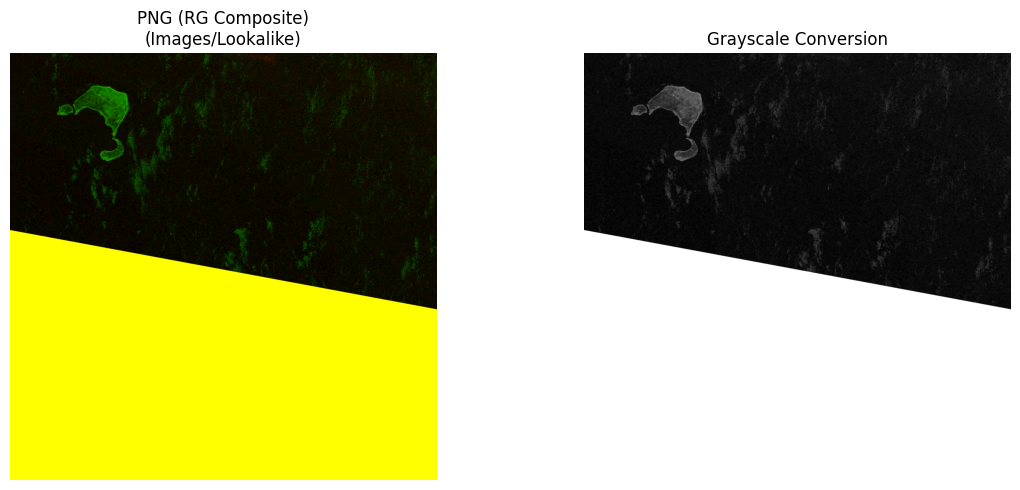

In [35]:
print("Displaying sample images from conversion process...")
display_sample_images(dataset_og_folder, dataset_png_folder, dataset_gray_folder)